# Random Forest Tuning: threshold + hyperparameters

Tuning is performed on **train/val only**. The test set is not loaded
in this notebook — the final model will be evaluated once on test
in `train_model.py` after all parameters are fixed.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_recall_curve, classification_report,
    f1_score, precision_score, recall_score
)

DATASET_PATH = "../datasets/synthetic_v1.csv"
FEATURE_COLS = ["amount", "account_age_days", "tx_last_hour", "transaction_hour"]
LABEL_COL = "is_fraud"

df = pd.read_csv(DATASET_PATH, parse_dates=["created_at"])
df = df.sort_values("created_at").reset_index(drop=True)

n = len(df)
train_end = int(n * 0.64)
val_end = int(n * 0.80)

train_df = df.iloc[:train_end]
val_df = df.iloc[train_end:val_end]

X_train, y_train = train_df[FEATURE_COLS], train_df[LABEL_COL]
X_val, y_val = val_df[FEATURE_COLS], val_df[LABEL_COL]

print(f"Train: {len(train_df)} rows ({y_train.mean():.2%} fraud)")
print(f"Val:   {len(val_df)} rows ({y_val.mean():.2%} fraud)")

Train: 12800 rows (1.81% fraud)
Val:   3200 rows (2.31% fraud)


## Part A — Baseline model

Same parameters as in `train_model.py`.

In [2]:
baseline_model = RandomForestClassifier(
    n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1
)
baseline_model.fit(X_train, y_train)
y_val_proba_baseline = baseline_model.predict_proba(X_val)[:, 1]

## Part B — Threshold tuning

Find the threshold that gives the best balance of Precision/Recall
(as measured by F1). The default 0.5 may not be optimal for
imbalanced fraud data.

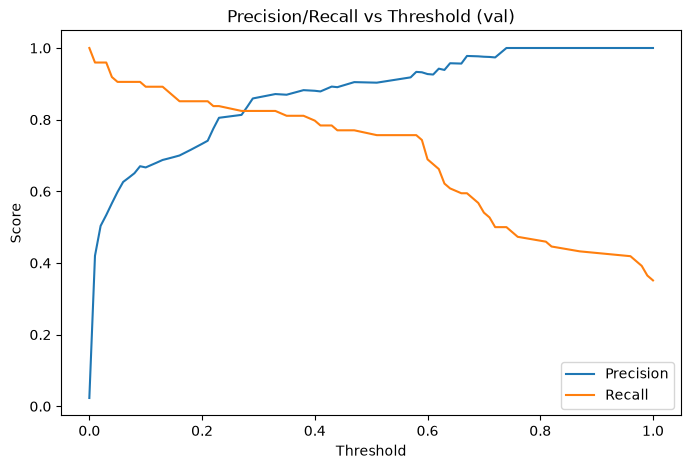

Best threshold by F1: 0.3300
F1 at best threshold: 0.8472


In [3]:
precisions, recalls, thresholds = precision_recall_curve(y_val, y_val_proba_baseline)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.title("Precision/Recall vs Threshold (val)")
plt.show()

f1_scores = [
    f1_score(y_val, (y_val_proba_baseline >= threshold).astype(int))
    for threshold in thresholds
]
best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Best threshold by F1: {best_threshold:.4f}")
print(f"F1 at best threshold: {f1_scores[np.argmax(f1_scores)]:.4f}")

## Part C — Hyperparameter tuning

Grid search over n_estimators, max_depth, min_samples_leaf.
Each combination is evaluated on the validation set using the
best threshold found above.

In [4]:
from sklearn.model_selection import ParameterGrid

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 5, 10],
}

results = []
for params in ParameterGrid(param_grid):
    model = RandomForestClassifier(
        **params, class_weight="balanced", random_state=42, n_jobs=-1
    )
    model.fit(X_train, y_train)
    y_val_proba = model.predict_proba(X_val)[:, 1]
    y_val_pred = (y_val_proba >= best_threshold).astype(int)
    results.append({
        **params,
        "precision": precision_score(y_val, y_val_pred),
        "recall": recall_score(y_val, y_val_pred),
        "f1": f1_score(y_val, y_val_pred),
    })

results_df = pd.DataFrame(results)
results_df.sort_values("f1", ascending=False).head(10)

,max_depth,min_samples_leaf,n_estimators,precision,recall,f1
0,NaN,1,100,0.871429,0.824324,0.847222
9,10.0,1,100,0.871429,0.824324,0.847222
18,20.0,1,100,0.871429,0.824324,0.847222
10,10.0,1,200,0.859155,0.824324,0.841379
2,NaN,1,300,0.869565,0.810811,0.839161
19,20.0,1,200,0.869565,0.810811,0.839161
1,NaN,1,200,0.869565,0.810811,0.839161
20,20.0,1,300,0.869565,0.810811,0.839161
11,10.0,1,300,0.845070,0.810811,0.827586
4,NaN,5,200,0.609091,0.905405,0.728261


## Results

- Best threshold: 0.33 
- Best hyperparameters: max_depth=None, min_samples_leaf=1, n_estimators=100
- Val metrics: Precision=0.871, Recall=0.824, F1=0.847

These values should be transferred to `ml/train_model.py` as constants
(not re-tuned in `train_model.py` — that script only performs the
final evaluation on test with the fixed parameters).